# Resonator spectroscopy

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal03_resonator_spectroscopy import ResonatorSpectroscopy

## Run parameters

In [11]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")  # Use None if no flux bias needed
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]
FREQUENCY_CENTER = 7.5e9
FREQUENCY_WIDTH = 20e6
FREQUENCY_POINTS = 201
REPETITIONS = 100

READOUT_AMPLITUDE = 0.08
OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = Path(r"..\config\dut_config_upd.json")  # Use None if param persisting is not required

## Hardware and experiment

In [12]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ResonatorSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Measurement

In [13]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    repetitions=REPETITIONS,
    readout_amplitude=READOUT_AMPLITUDE,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 6kB
Dimensions:           (acq_index_S21_q0: 201)
Coordinates:
    frequency_q0      (acq_index_S21_q0) float64 2kB 7.49e+09 ... 7.51e+09
  * acq_index_S21_q0  (acq_index_S21_q0) int64 2kB 0 1 2 3 4 ... 197 198 199 200
Data variables:
    S21_q0            (acq_index_S21_q0) complex128 3kB (nan+nanj) ... (nan+n...
Attributes:
    tuid:     20260806-170733-671-d55187

## Optional: Simulated data

In [9]:
dataset = experiment.simulated_data(
    frequency_center=7.5e9,
    frequency_width=40e6,
    frequency_points=401,
    resonance_frequency=7.495e9,
    loaded_quality_factor=8_000,
    coupling_quality_factor=12_000,
    signal_amplitude=1.0,
    noise=0.01,
    electrical_delay=20e-9,
    phase_offset=0.0,
    asymmetry=0.0,
    seed=42,
)
dataset

<xarray.Dataset> Size: 10kB
Dimensions:       (acq_index_S21_q0: 401)
Coordinates:
    frequency_q0  (acq_index_S21_q0) float64 3kB 7.48e+09 7.48e+09 ... 7.52e+09
Dimensions without coordinates: acq_index_S21_q0
Data variables:
    S21_q0        (acq_index_S21_q0) complex128 6kB (-0.7932188949188327+0.60...
Attributes:
    simulated:         True
    simulation_model:  qblox_scheduler.hanger_func_complex_SI

## Analysis

In [10]:
results = experiment.analysis()

for qubit, result in results.items():
    print(
        f"{qubit}: success={result.success}, "
        f"fr={result.frequency / 1e9:.9f} GHz, "
        f"Qi={result.internal_quality_factor:.3g}, "
        f"Qc={result.coupling_quality_factor:.3g}"
    )

q0: success=True, fr=7.494996173 GHz, Qi=2.39e+04, Qc=1.2e+04


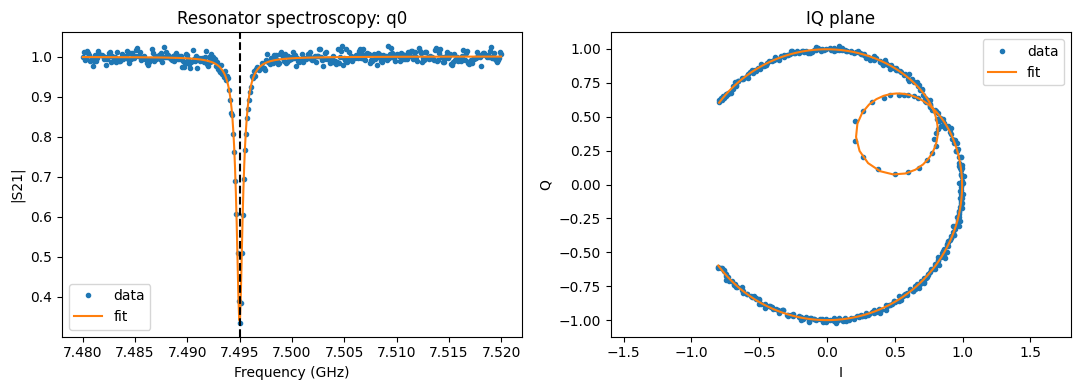

In [8]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [9]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to ..\config\dut_config_upd.json
